In [1]:
import os
import numpy as np
import time
import pandas as pd
from scipy import interpolate
import pickle
import sys
from astropy.io import ascii
from astropy.table import Table
from astropy import units as u
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap

In [2]:
decaps_cat_path = "/lustre/lrspec/users/4300/cube/Data/Phot/decaps_east.variable.parquet"
#decaps_lc_path =  "/lustre/lrspec/users/4300/cube/Data/Phot/var_curves_csv.tar.gz" don't touch this please

In [3]:
u = pd.read_parquet(decaps_cat_path)

In [15]:
u

,varID,masterID,RA_decaps,DEC_decaps,gdr3_id,gdr3_class,ogle_id,ogle_class,asassn_id,asassn_class,vivace_id,vivace_class,RA_lit,DEC_lit,coord_source_lit,Separation,period,period_from
0,1,60077925,270.516788,-30.512758,4044156221273016448,ECL,None,None,None,None,None,None,270.516790,-30.512743,GDR3,0.052253,0.257083,GDR3
1,2,60122603,270.470358,-30.486361,4044157290673797120,ECL,OGLE-BLG-ECL-258978,ECL-C,None,None,None,None,270.470338,-30.486295,GDR3,0.246285,0.962585,OGLE4
2,2,60372642,270.470331,-30.486222,4044157290673797120,ECL,OGLE-BLG-ECL-258978,ECL-C,None,None,None,None,270.470338,-30.486295,GDR3,0.264041,0.962585,OGLE4
3,2,60372727,270.470417,-30.486147,4044157290673797120,ECL,OGLE-BLG-ECL-258978,ECL-C,None,None,None,None,270.470338,-30.486295,GDR3,0.587124,0.962585,OGLE4
4,3,60006293,270.416138,-30.480722,4044157428075090176,LPV,OGLE-BLG-LPV-181462,LPV-SRV,None,None,None,None,270.416138,-30.480692,GDR3,0.106637,268.500000,OGLE3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199016,63500,52243284,270.567007,-30.051091,None,None,None,None,ASASSN-V J180216.08-300303.7,SR,None,None,270.566994,-30.051032,ASASSN,0.218767,147.000000,ASASSN
199017,63501,45240178,270.065065,-29.919359,None,None,None,None,ASASSN-V J180015.62-295509.5,SR,None,None,270.065067,-29.919298,ASASSN,0.216858,312.000000,ASASSN
199018,63502,44239139,271.776647,-29.705144,None,None,None,None,ASASSN-V J180706.40-294218.4,SR,None,None,271.776657,-29.705107,ASASSN,0.137179,492.000000,ASASSN
199019,63503,38212333,271.876784,-29.673771,None,None,None,None,ASASSN-V J180730.43-294025.4,SR,None,None,271.876796,-29.673730,ASASSN,0.152088,278.000000,ASASSN


In [5]:
u.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199021 entries, 0 to 199020
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   varID             199021 non-null  int64  
 1   masterID          199021 non-null  int64  
 2   RA_decaps         199021 non-null  float64
 3   DEC_decaps        199021 non-null  float64
 4   gdr3_id           70518 non-null   object 
 5   gdr3_class        70518 non-null   object 
 6   ogle_id           130417 non-null  object 
 7   ogle_class        130417 non-null  object 
 8   asassn_id         60 non-null      object 
 9   asassn_class      60 non-null      object 
 10  vivace_id         50929 non-null   object 
 11  vivace_class      50929 non-null   object 
 12  RA_lit            199021 non-null  float64
 13  DEC_lit           199021 non-null  float64
 14  coord_source_lit  199021 non-null  object 
 15  Separation        199021 non-null  float64
 16  period            17

In [16]:
u[u["masterID"]==8048865]

,varID,masterID,RA_decaps,DEC_decaps,gdr3_id,gdr3_class,ogle_id,ogle_class,asassn_id,asassn_class,vivace_id,vivace_class,RA_lit,DEC_lit,coord_source_lit,Separation,period,period_from
78293,25307,8048865,270.028726,-28.910224,None,None,OGLE-BLG-ECL-239319,ECL-NC,None,None,None,None,270.02871,-28.910167,OGLE4,0.210103,0.566176,OGLE4


LC file names: varID.csv

In [17]:
varID = 25307
LC_file_name = f"{varID}.csv"

In [19]:
!tar -zxvf /lustre/lrspec/users/4300/cube/Data/Phot/Decaps_LCs/var_curves_csv.tar.gz "{LC_file_name}"

25307.csv


^ That's really slow and will not work longterm

In [20]:
q = pd.read_csv(f"/lustre/lrspec/users/4300/cube/Data/Phot/Decaps_LCs/{LC_file_name}")

In [21]:
q.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3271 entries, 0 to 3270
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MJD       3271 non-null   float64
 1   M         3271 non-null   float64
 2   dM        3271 non-null   float64
 3   flux      3271 non-null   float64
 4   dflux     3271 non-null   float64
 5   type      3271 non-null   int64  
 6   Band      3271 non-null   object 
 7   masterID  3271 non-null   int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 204.6+ KB


In [12]:
np.unique(q["masterID"])

array([8048865, 8413025])

(array([   7.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        3264.]),
 array([-110.821  ,  -97.57442,  -84.32784,  -71.08126,  -57.83468,
         -44.5881 ,  -31.34152,  -18.09494,   -4.84836,    8.39822,
          21.6448 ]),
 <BarContainer object of 10 artists>)

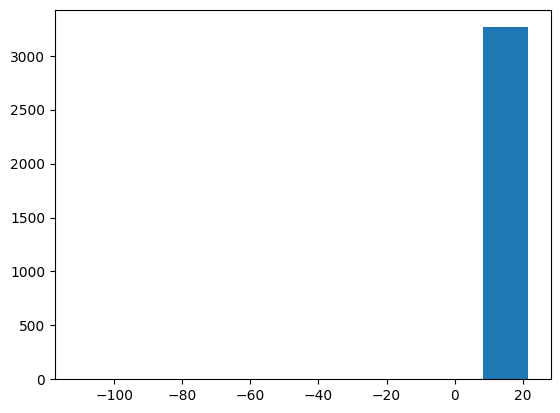

In [16]:
plt.hist(q["M"])

In [18]:
print(len(q))
q = q[q["M"]>0]
print(len(q))

3271
3264


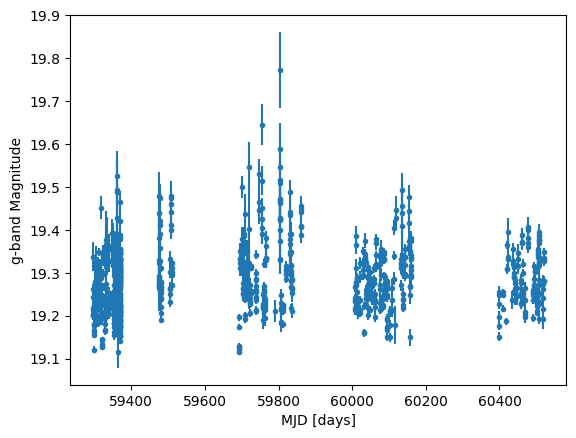

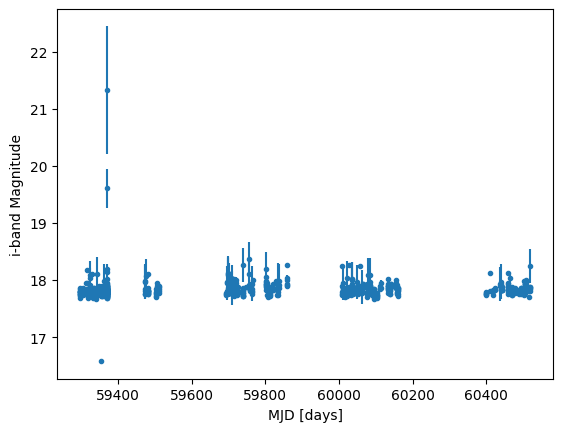

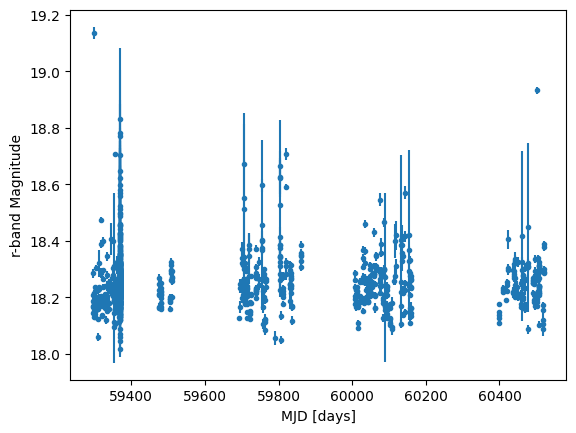

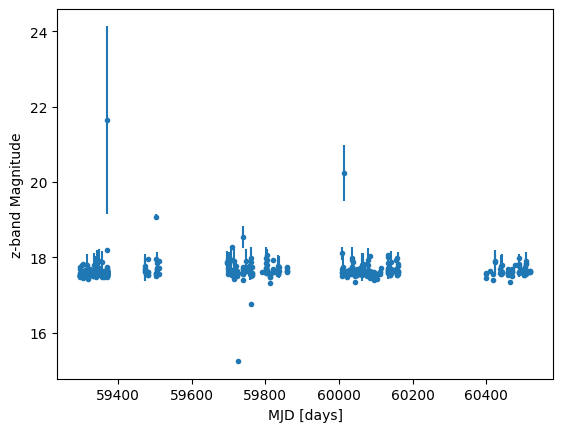

In [20]:
for band in np.unique(q["Band"]):
    plt.errorbar(q["MJD"][q["Band"]==band],q["M"][q["Band"]==band], yerr = q["dM"][q["Band"]==band], fmt = ".", #label = band
                )
    #plt.legend()
    plt.xlabel("MJD [days]")
    plt.ylabel(f"{band}-band Magnitude")
    plt.show()